In [1]:
from pathlib import Path
import pandas as pd

# String → Path-Objekt (raw string wegen Backslashes)
file_str = r"C:\Users\UlrichLehre\Downloads\ACOM1_LT_latest (1).csv"
file_path = Path(file_str)

# Optional: Existenz prüfen
if not file_path.exists():
    raise FileNotFoundError(f"{file_path} existiert nicht")

# CSV laden
df = pd.read_csv(file_path,
    sep=";",                # Semikolon
    decimal=",",            # deutsches Dezimal-Komma
    skiprows=16,            # Metadaten überspringen
    #na_values="---",        # Fehlwert
    parse_dates=[0],        # erste Spalte ist Datum
    dayfirst=True,           # deutsches Datumsformat
    encoding="cp1252"
)

print(df.shape)
df.head()

(1006, 2)


,24.02.2026 14:40:00,"1,7"
0,2026-02-24 14:50:00,2.2
1,2026-02-24 15:00:00,2.2
2,2026-02-24 15:10:00,2.1
3,2026-02-24 15:20:00,2.1
4,2026-02-24 15:30:00,2.5


In [2]:
df = df.rename(columns={
    df.columns[0]: "Datum",
    df.columns[1]: "Temperatur"
})

<Axes: xlabel='Datum'>

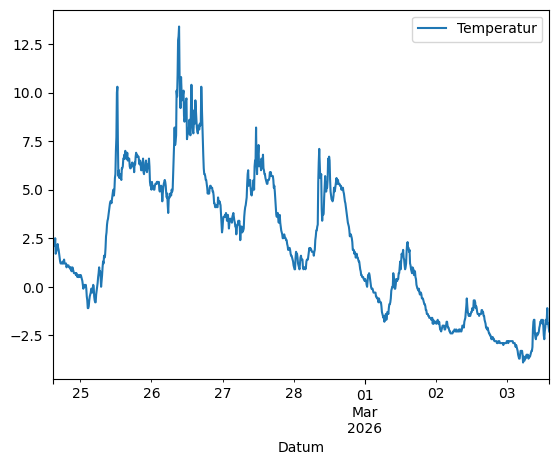

In [3]:
df.plot('Datum','Temperatur')

In [4]:
x = df["Datum"]
y = df["Temperatur"]

In [5]:
import matplotlib.pyplot as plt

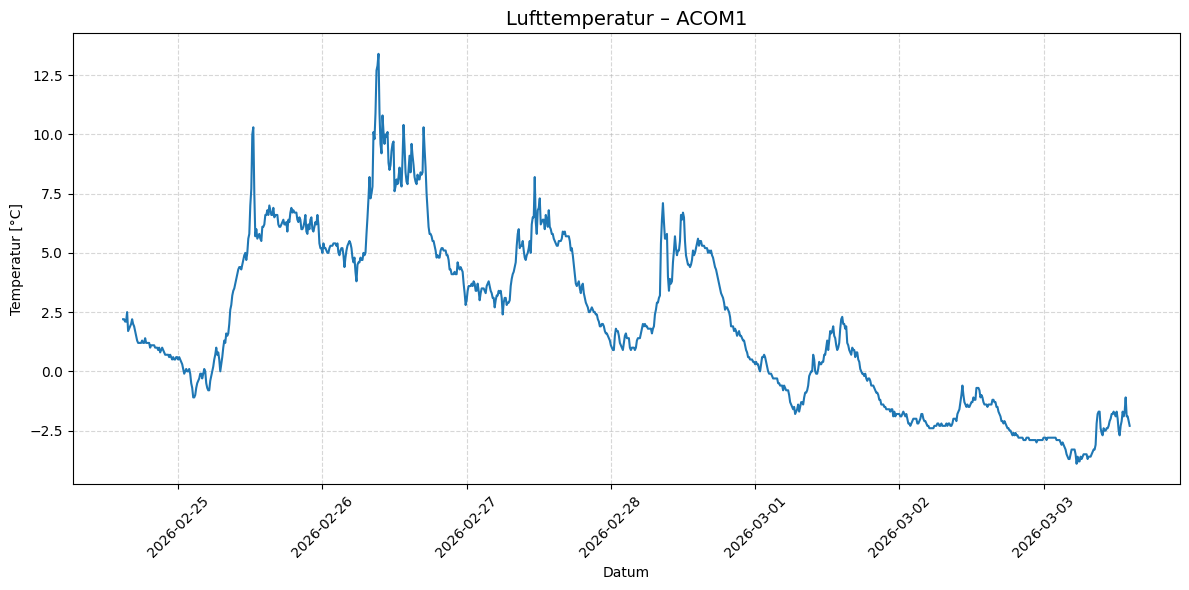

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
    
ax.plot(x, y, linewidth=1.5)

ax.set_title("Lufttemperatur – ACOM1", fontsize=14)
ax.set_xlabel("Datum")
ax.set_ylabel("Temperatur [°C]")

ax.grid(True, which="both", linestyle="--", alpha=0.5)

# X-Achse 45° drehen
plt.xticks(rotation=45)

plt.tight_layout()


fig.savefig('../plots/plot2.pdf')

plt.show()

In [6]:
folder = Path(r"C:\Users\UlrichLehre\Downloads")

csv_files = list(folder.glob("*.csv"))

for f in csv_files:
    print(f)

C:\Users\UlrichLehre\Downloads\ACOM1_LT_latest (1).csv
C:\Users\UlrichLehre\Downloads\ACOM1_LT_latest.csv
C:\Users\UlrichLehre\Downloads\Messstationen Zehnminutendaten v2 Datensatz_20260101T0000_20260303T1500.csv


In [7]:
df_lienz = pd.read_csv(csv_files[2])

In [8]:
df_lienz

,time,station,tl,rf
0,2026-01-01T00:00+00:00,17901,-4.2,51.0
1,2026-01-01T00:10+00:00,17901,-5.4,56.0
2,2026-01-01T00:20+00:00,17901,-5.6,58.0
3,2026-01-01T00:30+00:00,17901,-5.6,59.0
4,2026-01-01T00:40+00:00,17901,-6.6,62.0
...,...,...,...,...
8870,2026-03-03T14:20+00:00,17901,NaN,NaN
8871,2026-03-03T14:30+00:00,17901,NaN,NaN
8872,2026-03-03T14:40+00:00,17901,NaN,NaN
8873,2026-03-03T14:50+00:00,17901,NaN,NaN


In [10]:
df_lienz["time"] = pd.to_datetime(df_lienz["time"])
df_lienz = df_lienz.set_index("time")

In [15]:
df_lienz_resampled = df_lienz.resample('1h').mean()

In [16]:
df_lienz_resampled

,station,tl,rf
time,,,
2026-01-01 00:00:00+00:00,17901.0,-5.666667,57.500000
2026-01-01 01:00:00+00:00,17901.0,-7.800000,67.500000
2026-01-01 02:00:00+00:00,17901.0,-8.800000,70.333333
2026-01-01 03:00:00+00:00,17901.0,-9.683333,75.666667
2026-01-01 04:00:00+00:00,17901.0,-11.266667,81.333333
...,...,...,...
2026-03-03 11:00:00+00:00,17901.0,9.650000,60.500000
2026-03-03 12:00:00+00:00,17901.0,11.866667,45.833333
2026-03-03 13:00:00+00:00,17901.0,11.933333,47.333333


In [17]:
df_feb = df_lienz_resampled.loc["2026-02"]

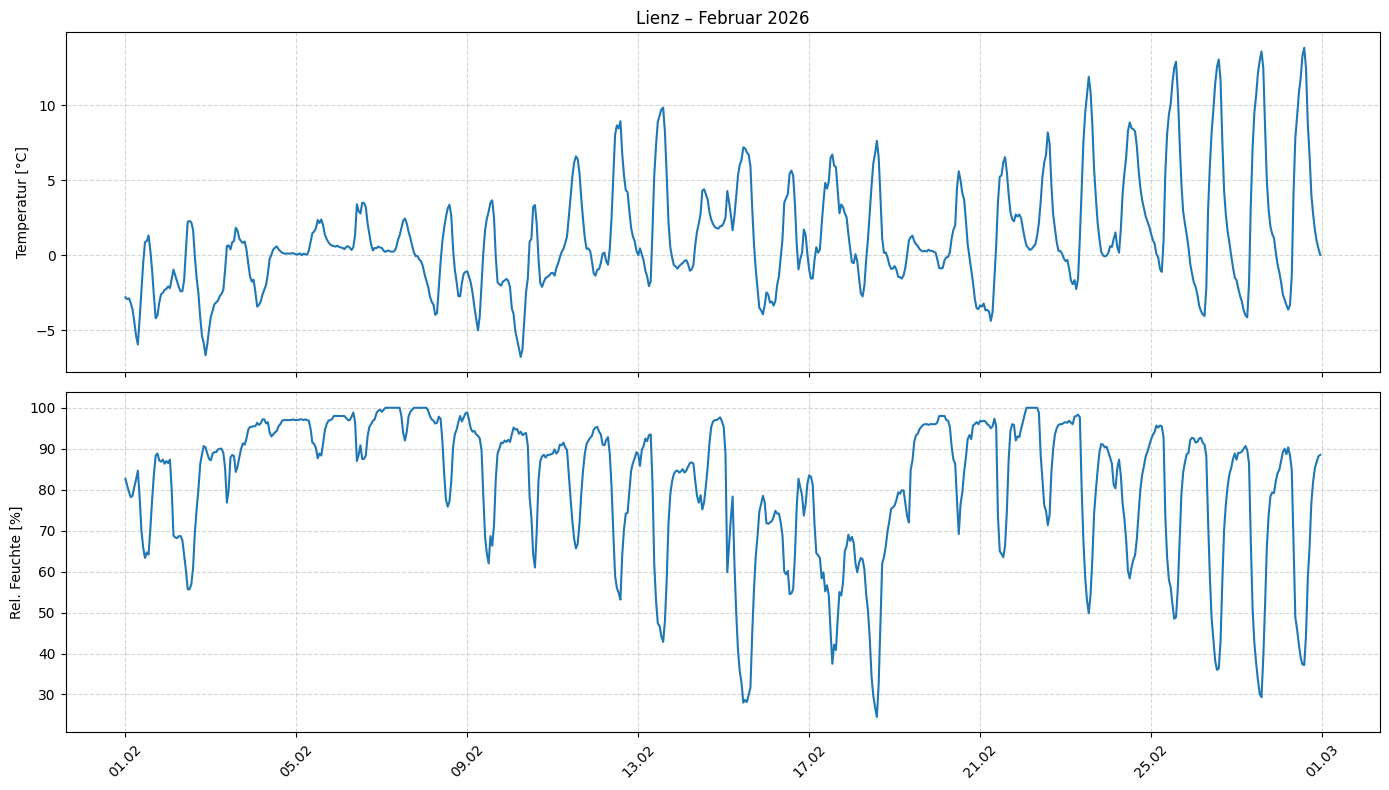

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True
)

# --- Temperatur ---
ax[0].plot(df_feb.index, df_feb["tl"], linewidth=1.5)
ax[0].set_ylabel("Temperatur [°C]")
ax[0].set_title("Lienz – Februar 2026")
ax[0].grid(True, linestyle="--", alpha=0.5)

# --- Relative Feuchte ---
ax[1].plot(df_feb.index, df_feb["rf"], linewidth=1.5)
ax[1].set_ylabel("Rel. Feuchte [%]")
ax[1].grid(True, linestyle="--", alpha=0.5)

# --- Zeitformatierung ---
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()